# Phase 1 Step 3 — 데이터 전처리 & 증강

**목표:** 레이블 데이터(172,950개)를 모델 학습에 적합한 형태로 변환하고, 클래스 불균형을 처리하며 Albumentations 기반 데이터 증강 파이프라인을 구축한다.

| 항목 | 내용 |
|------|------|
| 분류 분리 | Train 70% / Val 15% / Test 15% (Stratified) |
| 리사이즈 | 가변 크기 → **64×64** (INTER_NEAREST) |
| 정규화 | 픽셀값 0~2 → **0.0~1.0** (÷2) |
| 불균형 처리 | WeightedRandomSampler + CrossEntropyLoss Class Weight |
| 증강 라이브러리 | Albumentations 1.4.21 |
| 산출물 | `configs/augmentation_config.yaml`, `data/processed/split_indices.pkl` |

## 1. 환경 설정

In [1]:
import os
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import yaml
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore')
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

# ── 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로
DATA_PATH    = Path('data/raw/LSWMD.pkl')
PROCESSED_DIR = Path('data/processed')
CONFIGS_DIR  = Path('configs')
ANALYSIS_DIR = Path('analysis')
for d in [PROCESSED_DIR, CONFIGS_DIR, ANALYSIS_DIR]:
    d.mkdir(exist_ok=True)

# ── 시드
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── 클래스 정의
CLASS_ORDER = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']
NUM_CLASSES = len(CLASS_ORDER)
LABEL_MAP   = {cls: idx for idx, cls in enumerate(CLASS_ORDER)}

# ── 전처리 상수
RESIZE       = (64, 64)   # (W, H) for cv2.resize
NORM_DIVISOR = 2.0        # 픽셀 0~2 → 0.0~1.0
BATCH_SIZE   = 64
NUM_WORKERS  = 2

print(f'albumentations:  {A.__version__}')
print(f'PyTorch:         {torch.__version__}')
print(f'CUDA 사용 가능:  {torch.cuda.is_available()}')
print(f'LABEL_MAP: {LABEL_MAP}')

c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\.venv\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


albumentations:  1.4.21
PyTorch:         2.6.0+cu124
CUDA 사용 가능:  True
LABEL_MAP: {'none': 0, 'Center': 1, 'Donut': 2, 'Edge-Loc': 3, 'Edge-Ring': 4, 'Loc': 5, 'Near-full': 6, 'Random': 7, 'Scratch': 8}


## 2. 데이터 로드 및 필터링

In [2]:
print('pickle 로드 중...')
df = pd.read_pickle(DATA_PATH)

def extract_label(val):
    if isinstance(val, (list, np.ndarray)):
        flat = np.array(val).flatten()
        return str(flat[0]) if len(flat) > 0 else 'unknown'
    return str(val)

df['failureType_clean'] = df['failureType'].apply(extract_label)

# unknown(미레이블) 제거 → 172,950개
labeled_df = df[df['failureType_clean'] != 'unknown'].reset_index(drop=True)

print(f'레이블 데이터: {len(labeled_df):,}개')
print(f'클래스 분포:')
dist = labeled_df['failureType_clean'].value_counts()
for cls in CLASS_ORDER:
    print(f'  {cls:<12}: {dist.get(cls, 0):>6,}개')

pickle 로드 중...
레이블 데이터: 172,950개
클래스 분포:
  none        : 147,431개
  Center      :  4,294개
  Donut       :    555개
  Edge-Loc    :  5,189개
  Edge-Ring   :  9,680개
  Loc         :  3,593개
  Near-full   :    149개
  Random      :    866개
  Scratch     :  1,193개


## 3. 웨이퍼 맵 추출 및 전처리 검증

- **리사이즈**: `cv2.INTER_NEAREST` — 이산 픽셀값(0/1/2)의 의미 보존
- **정규화**: `÷2.0` → 0.0(빈영역), 0.5(정상다이), 1.0(불량다이)

In [4]:
print('웨이퍼 맵 및 레이블 추출 중...')
all_maps       = list(labeled_df['waferMap'].values)
raw_labels     = list(labeled_df['failureType_clean'].values)
encoded_labels = [LABEL_MAP[lbl] for lbl in raw_labels]
print(f'총 샘플: {len(all_maps):,}개')

# ── 단일 샘플 전처리 함수 (시각화/검증용으로만 사용)
def preprocess_map(wmap):
    arr = wmap.astype(np.float32) / NORM_DIVISOR
    return cv2.resize(arr, RESIZE, interpolation=cv2.INTER_NEAREST)

sample = preprocess_map(all_maps[0])
print(f'전처리 샘플 shape: {sample.shape}, 픽셀값: {np.unique(sample)}')

# ══════════════════════════════════════════════════════════════════
# 전체 맵을 (N, 64, 64) uint8 배열로 일괄 전처리 (1회만 실행)
#
# [왜 일괄 전처리?]
#  - DataLoader num_workers > 0 (Windows spawn) 시, 워커마다
#    self.maps 전체(121,065개 가변 배열)를 pickle 직렬화 → 수 분 소요
#  - __getitem__마다 cv2.resize 반복 → 훈련 중 수백만 회 비효율
#  - 일괄 전처리: 1개 연속 배열 → 직렬화 최소, __getitem__은 정규화만
#
# [메모리] 172,950 × 64 × 64 × 1B (uint8) ≈ 676 MB
# ══════════════════════════════════════════════════════════════════
import time
n = len(all_maps)
print(f'\n전체 {n:,}개 맵을 64×64 uint8 배열로 일괄 전처리 중...')
t0 = time.time()

all_maps_resized = np.empty((n, 64, 64), dtype=np.uint8)
for i, wmap in enumerate(all_maps):
    all_maps_resized[i] = cv2.resize(
        wmap.astype(np.uint8), RESIZE, interpolation=cv2.INTER_NEAREST
    )
    if (i + 1) % 40000 == 0:
        elapsed = time.time() - t0
        print(f'  {i+1:>7,} / {n:,}  ({(i+1)/n*100:.0f}%)  {elapsed:.1f}s 경과')

elapsed = time.time() - t0
print(f'\n일괄 전처리 완료! ({elapsed:.1f}s)')
print(f'  shape : {all_maps_resized.shape}  dtype: {all_maps_resized.dtype}')
print(f'  메모리: {all_maps_resized.nbytes / 1024**2:.0f} MB')
print(f'  픽셀값 고유: {np.unique(all_maps_resized)} → __getitem__에서 ÷2 → 0.0/0.5/1.0')

웨이퍼 맵 및 레이블 추출 중...
총 샘플: 172,950개
전처리 샘플 shape: (64, 64), 픽셀값: [0.  0.5 1. ]

전체 172,950개 맵을 64×64 uint8 배열로 일괄 전처리 중...
   40,000 / 172,950  (23%)  0.4s 경과
   80,000 / 172,950  (46%)  0.8s 경과
  120,000 / 172,950  (69%)  1.1s 경과
  160,000 / 172,950  (93%)  1.5s 경과

일괄 전처리 완료! (1.6s)
  shape : (172950, 64, 64)  dtype: uint8
  메모리: 676 MB
  픽셀값 고유: [0 1 2] → __getitem__에서 ÷2 → 0.0/0.5/1.0


## 4. Stratified Train / Val / Test 분리 (70 / 15 / 15)

In [5]:
X = np.arange(len(encoded_labels))
y = np.array(encoded_labels)

# 1차: 70% train, 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(X, y))

# 2차: temp를 50/50으로 → val 15%, test 15%
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(temp_idx, y[temp_idx]))
val_idx  = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

print('=== 분리 결과 ===')
print(f'Train: {len(train_idx):>7,}개  ({len(train_idx)/len(X)*100:.1f}%)')
print(f'Val:   {len(val_idx):>7,}개  ({len(val_idx)/len(X)*100:.1f}%)')
print(f'Test:  {len(test_idx):>7,}개  ({len(test_idx)/len(X)*100:.1f}%)')

print('\n=== 클래스별 분포 검증 (Stratified 확인) ===')
print(f"{'클래스':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print('-' * 42)
for cls_idx, cls in enumerate(CLASS_ORDER):
    tr = (y[train_idx] == cls_idx).sum()
    vl = (y[val_idx]   == cls_idx).sum()
    ts = (y[test_idx]  == cls_idx).sum()
    print(f'{cls:<12} {tr:>8,} {vl:>8,} {ts:>8,}')

=== 분리 결과 ===
Train: 121,065개  (70.0%)
Val:    25,942개  (15.0%)
Test:   25,943개  (15.0%)

=== 클래스별 분포 검증 (Stratified 확인) ===
클래스             Train      Val     Test
------------------------------------------
none          103,202   22,114   22,115
Center          3,006      644      644
Donut             389       83       83
Edge-Loc        3,632      778      779
Edge-Ring       6,776    1,452    1,452
Loc             2,515      539      539
Near-full         104       23       22
Random            606      130      130
Scratch           835      179      179


## 5. 클래스 가중치 계산

두 가지 가중치를 계산한다.
- **`class_weight_tensor`**: `nn.CrossEntropyLoss(weight=...)` 에 직접 전달
- **`sample_weights`**: `WeightedRandomSampler` 에 전달 → 미니배치 내 클래스 균형

In [6]:
train_labels_arr = y[train_idx]

# sklearn compute_class_weight: 'balanced' → n_samples / (n_classes * count_per_class)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels_arr
)
class_weight_tensor = torch.FloatTensor(class_weights)

# WeightedRandomSampler용 샘플별 가중치
sample_weights   = class_weights[train_labels_arr]
weighted_sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(train_labels_arr),
    replacement=True
)

print('=== 클래스별 가중치 (CrossEntropyLoss) ===')
print(f"{'클래스':<12} {'학습 샘플':>10} {'가중치':>10}")
print('-' * 36)
for i, cls in enumerate(CLASS_ORDER):
    cnt = (train_labels_arr == i).sum()
    print(f'{cls:<12} {cnt:>10,} {class_weights[i]:>10.4f}')

print(f'\nclass_weight_tensor shape: {class_weight_tensor.shape}')
print(f'사용 예시: criterion = nn.CrossEntropyLoss(weight=class_weight_tensor.cuda())')

=== 클래스별 가중치 (CrossEntropyLoss) ===
클래스               학습 샘플        가중치
------------------------------------
none            103,202     0.1303
Center            3,006     4.4749
Donut               389    34.5801
Edge-Loc          3,632     3.7037
Edge-Ring         6,776     1.9852
Loc               2,515     5.3486
Near-full           104   129.3429
Random              606    22.1975
Scratch             835    16.1098

class_weight_tensor shape: torch.Size([9])
사용 예시: criterion = nn.CrossEntropyLoss(weight=class_weight_tensor.cuda())


## 6. Albumentations 증강 파이프라인 구축

In [7]:
# ── 학습용 증강 파이프라인
# 웨이퍼 맵은 픽셀값이 의미를 가짐(0=빈, 0.5=정상, 1.0=불량)
# 공간 변환(회전/반전)은 패턴 의미 보존 / 픽셀값 변환은 소폭 적용
train_transform = A.Compose([
    A.Rotate(limit=20, border_mode=0, value=0.0, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    A.Blur(blur_limit=3, p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.2),
    A.CoarseDropout(
        max_holes=4, max_height=8, max_width=8,
        min_holes=1, min_height=4, min_width=4,
        fill_value=0.0, p=0.3
    ),
])

# ── 검증/테스트용 (증강 없음)
val_transform = None

print('=== Albumentations 학습 증강 파이프라인 ===')
for t in train_transform.transforms:
    print(f'  {type(t).__name__:<30} p={t.p}')

# ── YAML 설정 파일 저장
aug_config = {
    'preprocessing': {
        'resize': list(RESIZE),
        'normalize_divisor': NORM_DIVISOR,
        'interpolation': 'INTER_NEAREST',
        'input_channels': 1,
        'pixel_values': {'0.0': 'empty_area', '0.5': 'normal_die', '1.0': 'defective_die'},
    },
    'train_augmentation': {
        'Rotate':                   {'limit': 20, 'border_mode': 0, 'p': 0.5},
        'HorizontalFlip':           {'p': 0.5},
        'VerticalFlip':             {'p': 0.5},
        'GaussNoise':               {'var_limit': [0.001, 0.005], 'p': 0.3},
        'Blur':                     {'blur_limit': 3, 'p': 0.2},
        'RandomBrightnessContrast': {'brightness_limit': 0.05, 'contrast_limit': 0.05, 'p': 0.2},
        'CoarseDropout':            {'max_holes': 4, 'max_height': 8, 'max_width': 8, 'fill_value': 0.0, 'p': 0.3},
    },
    'val_test_augmentation': 'none',
    'dataloader': {
        'batch_size': BATCH_SIZE,
        'num_workers': NUM_WORKERS,
        'pin_memory': True,
        'train_sampler': 'WeightedRandomSampler',
    },
    'class_order': CLASS_ORDER,
    'label_map': LABEL_MAP,
    'albumentations_version': A.__version__,
}

yaml_path = CONFIGS_DIR / 'augmentation_config.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(aug_config, f, default_flow_style=False, allow_unicode=True, sort_keys=False)

print(f'\nYAML 저장 완료: {yaml_path}')

=== Albumentations 학습 증강 파이프라인 ===
  Rotate                         p=0.5
  HorizontalFlip                 p=0.5
  VerticalFlip                   p=0.5
  GaussNoise                     p=0.3
  Blur                           p=0.2
  RandomBrightnessContrast       p=0.2
  CoarseDropout                  p=0.3

YAML 저장 완료: configs\augmentation_config.yaml


## 7. PyTorch Dataset & DataLoader 구현

In [8]:
class WaferMapDataset(Dataset):
    """WM-811K 웨이퍼 맵 PyTorch Dataset

    maps_array : (N, 64, 64) uint8 — 미리 리사이즈된 배열
    __getitem__: uint8 → float32 ÷2 정규화만 수행 (resize 없음)
    반환 텐서 : (1, 64, 64) float32  |  레이블: long (0~8)
    """

    def __init__(self, maps_array, labels, transform=None, norm_divisor=2.0):
        self.maps_array   = maps_array    # (N, 64, 64) uint8, 연속 메모리
        self.labels       = labels        # 1D int array
        self.transform    = transform
        self.norm_divisor = norm_divisor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # resize 없음 — 이미 64×64 / uint8→float32 정규화만
        wmap = self.maps_array[idx].astype(np.float32) / self.norm_divisor

        if self.transform is not None:
            wmap = self.transform(
                image=wmap[:, :, np.newaxis]
            )['image'][:, :, 0]

        tensor = torch.from_numpy(np.clip(wmap, 0.0, 1.0).copy()).unsqueeze(0)
        label  = torch.tensor(self.labels[idx], dtype=torch.long)
        return tensor, label


# ── numpy 슬라이싱으로 서브셋 생성 (list comprehension 불필요, 훨씬 빠름)
train_maps   = all_maps_resized[train_idx]   # (121065, 64, 64) uint8 view
val_maps     = all_maps_resized[val_idx]     # (25942,  64, 64) uint8 view
test_maps    = all_maps_resized[test_idx]    # (25943,  64, 64) uint8 view
train_labels = y[train_idx].astype(int)
val_labels   = y[val_idx].astype(int)
test_labels  = y[test_idx].astype(int)

train_dataset = WaferMapDataset(train_maps, train_labels, transform=train_transform)
val_dataset   = WaferMapDataset(val_maps,   val_labels)
test_dataset  = WaferMapDataset(test_maps,  test_labels)

# ── DataLoader
# num_workers=0: Windows/Jupyter 환경 필수 설정
#   - Windows는 spawn 방식 → 워커 프로세스마다 Python 재시작 + 데이터 pickle 전송
#   - 676MB 연속 배열이라도 spawn 오버헤드 >> 멀티코어 이득
#   - 단일 프로세스(0)가 실질적으로 더 빠름 (Linux 서버에선 2~4 권장)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=weighted_sampler, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0
)

# ── 배치 검증
imgs, lbls = next(iter(train_loader))
print('=== DataLoader 검증 ===')
print(f'Train loader:  {len(train_loader):>4}배치  (샘플 {len(train_dataset):,}개)')
print(f'Val loader:    {len(val_loader):>4}배치  (샘플 {len(val_dataset):,}개)')
print(f'Test loader:   {len(test_loader):>4}배치  (샘플 {len(test_dataset):,}개)')
print(f'\n배치 텐서 shape : images={imgs.shape}, labels={lbls.shape}')
print(f'dtype           : {imgs.dtype}')
print(f'값 범위         : [{imgs.min():.3f}, {imgs.max():.3f}]')

=== DataLoader 검증 ===
Train loader:  1892배치  (샘플 121,065개)
Val loader:     406배치  (샘플 25,942개)
Test loader:    406배치  (샘플 25,943개)

배치 텐서 shape : images=torch.Size([64, 1, 64, 64]), labels=torch.Size([64])
dtype           : torch.float32
값 범위         : [0.000, 1.000]


## 8. 증강 효과 검증 시각화

각 불량 클래스별 원본(Original)과 증강(Augmented ×3) 비교

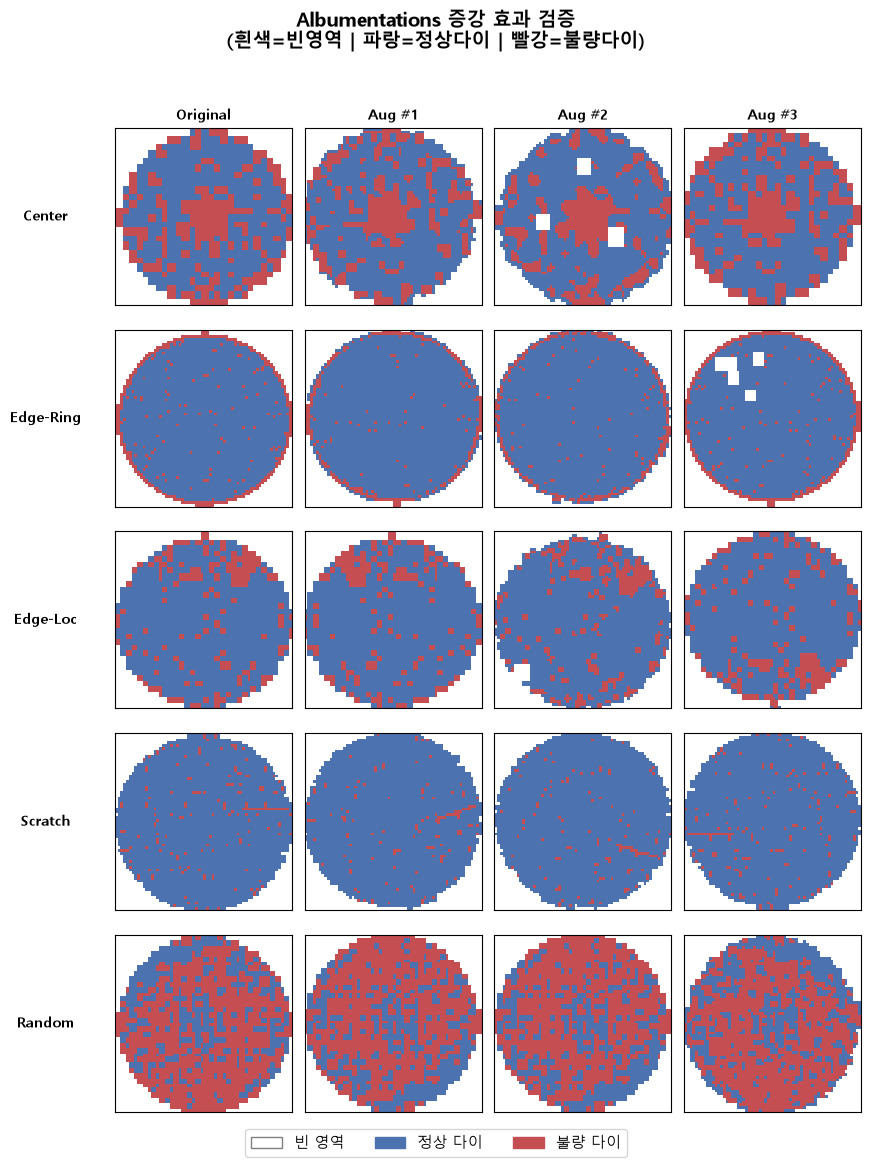

저장 완료: analysis\augmentation_comparison.png


In [9]:
WAFER_CMAP = mcolors.ListedColormap(['#FFFFFF', '#4C72B0', '#C44E52'])
WAFER_NORM = mcolors.BoundaryNorm([0, 0.25, 0.75, 1.01], WAFER_CMAP.N)

SHOW_CLASSES = ['Center', 'Edge-Ring', 'Edge-Loc', 'Scratch', 'Random']
N_AUG = 3   # 증강 버전 수
N_COL = 1 + N_AUG  # original + augmented

fig, axes = plt.subplots(len(SHOW_CLASSES), N_COL,
                          figsize=(N_COL * 2.2, len(SHOW_CLASSES) * 2.2))
fig.suptitle('Albumentations 증강 효과 검증\n(흰색=빈영역 | 파랑=정상다이 | 빨강=불량다이)',
             fontsize=14, fontweight='bold', y=1.02)

for row, cls in enumerate(SHOW_CLASSES):
    cls_idx = LABEL_MAP[cls]
    # 해당 클래스의 train 샘플 중 하나 선택
    candidate_idx = np.where(y[train_idx] == cls_idx)[0]
    np.random.seed(SEED + row)
    chosen = train_idx[np.random.choice(candidate_idx)]
    raw_map = preprocess_map(all_maps[chosen])

    for col in range(N_COL):
        ax = axes[row][col]
        if col == 0:
            ax.imshow(raw_map, cmap=WAFER_CMAP, norm=WAFER_NORM, interpolation='nearest')
            if row == 0:
                ax.set_title('Original', fontsize=10, fontweight='bold')
            ax.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0,
                         labelpad=50, va='center')
        else:
            np.random.seed(SEED + row * 100 + col)
            aug_map = train_transform(
                image=raw_map[:, :, np.newaxis]
            )['image'][:, :, 0]
            ax.imshow(np.clip(aug_map, 0, 1), cmap=WAFER_CMAP, norm=WAFER_NORM,
                     interpolation='nearest')
            if row == 0:
                ax.set_title(f'Aug #{col}', fontsize=10, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

legend_patches = [
    mpatches.Patch(color='#FFFFFF', label='빈 영역', ec='gray'),
    mpatches.Patch(color='#4C72B0', label='정상 다이'),
    mpatches.Patch(color='#C44E52', label='불량 다이'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
save_path = ANALYSIS_DIR / 'augmentation_comparison.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'저장 완료: {save_path}')

## 9. WeightedRandomSampler 효과 시각화

원본 클래스 불균형 vs WeightedRandomSampler 적용 후 미니배치 분포 비교

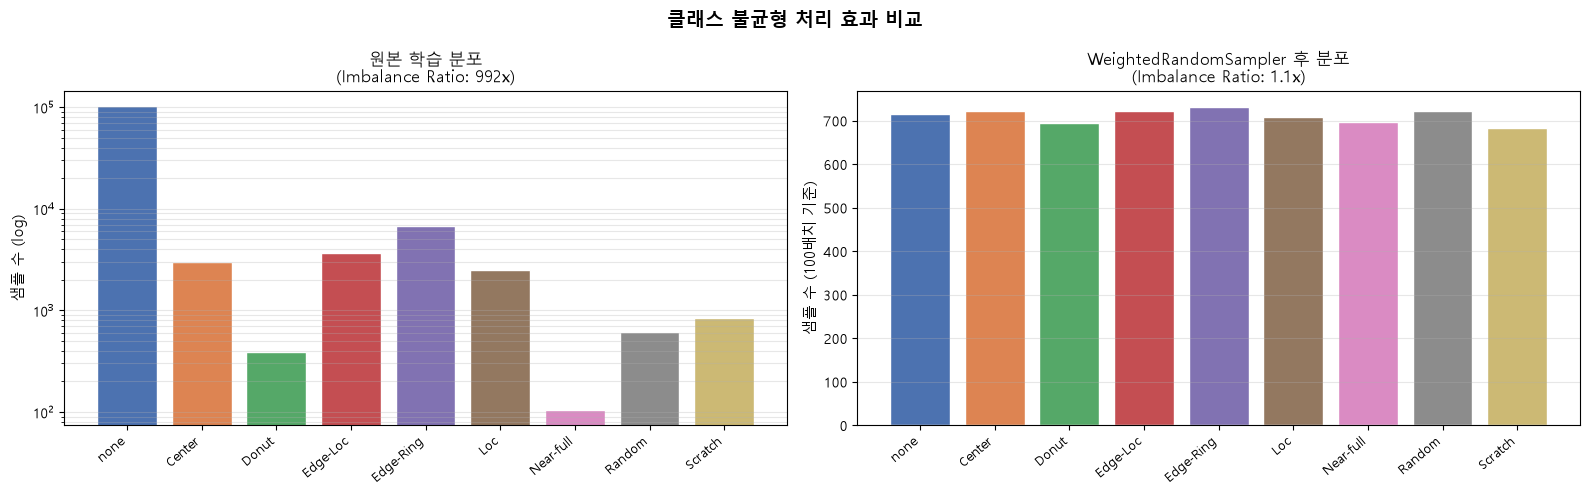

저장 완료: analysis\sampler_distribution.png


In [10]:
# 100배치 샘플링하여 실제 분포 측정
N_BATCHES = 100
sampled_labels = []
for i, (_, lbl) in enumerate(train_loader):
    sampled_labels.extend(lbl.numpy().tolist())
    if i >= N_BATCHES - 1:
        break

sampled_arr = np.array(sampled_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('클래스 불균형 처리 효과 비교', fontsize=14, fontweight='bold')

CLASS_COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
                '#937860','#DA8BC3','#8C8C8C','#CCB974']

# 원본 학습 분포
orig_counts = [(y[train_idx] == i).sum() for i in range(NUM_CLASSES)]
axes[0].bar(CLASS_ORDER, orig_counts, color=CLASS_COLORS, edgecolor='white')
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels(CLASS_ORDER, rotation=40, ha='right', fontsize=9)
axes[0].set_yscale('log')
axes[0].set_ylabel('샘플 수 (log)', fontsize=11)
axes[0].set_title(f'원본 학습 분포\n(Imbalance Ratio: {max(orig_counts)/min(orig_counts):.0f}x)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3, which='both')

# WeightedRandomSampler 후 분포
samp_counts = [(sampled_arr == i).sum() for i in range(NUM_CLASSES)]
axes[1].bar(CLASS_ORDER, samp_counts, color=CLASS_COLORS, edgecolor='white')
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels(CLASS_ORDER, rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel(f'샘플 수 ({N_BATCHES}배치 기준)', fontsize=11)
axes[1].set_title(f'WeightedRandomSampler 후 분포\n(Imbalance Ratio: {max(samp_counts)/max(min(samp_counts),1):.1f}x)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = ANALYSIS_DIR / 'sampler_distribution.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'저장 완료: {save_path}')

## 10. 산출물 저장 및 src/data_loader.py 업데이트

In [11]:
# ── split indices + 메타데이터 저장
split_data = {
    'train_idx':      train_idx,
    'val_idx':        val_idx,
    'test_idx':       test_idx,
    'encoded_labels': np.array(encoded_labels),
    'label_map':      LABEL_MAP,
    'class_order':    CLASS_ORDER,
    'class_weights':  class_weights,
    'split_ratio':    {'train': 0.70, 'val': 0.15, 'test': 0.15},
    'seed':           SEED,
}
pkl_path = PROCESSED_DIR / 'split_indices.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(split_data, f)
print(f'split_indices.pkl 저장: {pkl_path}')

np.save(PROCESSED_DIR / 'class_weights.npy', class_weights)
print(f'class_weights.npy 저장: {PROCESSED_DIR / "class_weights.npy"}')

# all_maps_resized도 저장 (04_baseline_model에서 재사용)
resized_path = PROCESSED_DIR / 'all_maps_resized.npy'
np.save(resized_path, all_maps_resized)
print(f'all_maps_resized.npy 저장: {resized_path}  ({all_maps_resized.nbytes/1024**2:.0f} MB)')

print()
print('=== Phase 1 Step 3 완료 ===')
print()
print('# 04_baseline_model.ipynb 상단에 복사하여 사용:')
print("""import pickle
import numpy as np
from pathlib import Path
from src.data_loader import WaferMapDataset, get_dataloaders

all_maps_resized = np.load('data/processed/all_maps_resized.npy')   # (172950, 64, 64) uint8

with open('data/processed/split_indices.pkl', 'rb') as f:
    split = pickle.load(f)

train_loader, val_loader, test_loader = get_dataloaders(
    all_maps_resized, split, batch_size=64
)""")
print()
print('다음 단계: 04_baseline_model.ipynb')

split_indices.pkl 저장: data\processed\split_indices.pkl
class_weights.npy 저장: data\processed\class_weights.npy
all_maps_resized.npy 저장: data\processed\all_maps_resized.npy  (676 MB)

=== Phase 1 Step 3 완료 ===

# 04_baseline_model.ipynb 상단에 복사하여 사용:
import pickle
import numpy as np
from pathlib import Path
from src.data_loader import WaferMapDataset, get_dataloaders

all_maps_resized = np.load('data/processed/all_maps_resized.npy')   # (172950, 64, 64) uint8

with open('data/processed/split_indices.pkl', 'rb') as f:
    split = pickle.load(f)

train_loader, val_loader, test_loader = get_dataloaders(
    all_maps_resized, split, batch_size=64
)

다음 단계: 04_baseline_model.ipynb


In [12]:
# ── src/data_loader.py 업데이트
DATA_LOADER_CODE = '''"""WM-811K 웨이퍼 맵 Dataset & DataLoader 유틸리티 (Phase 1 Step 3)

사용법:
    all_maps_resized = np.load(\'data/processed/all_maps_resized.npy\')  # (N,64,64) uint8
    with open(\'data/processed/split_indices.pkl\', \'rb\') as f:
        split = pickle.load(f)
    train_loader, val_loader, test_loader = get_dataloaders(
        all_maps_resized, split, batch_size=64
    )
"""

import pickle
import numpy as np
import albumentations as A

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

CLASS_ORDER  = [\'none\', \'Center\', \'Donut\', \'Edge-Loc\', \'Edge-Ring\',
                \'Loc\', \'Near-full\', \'Random\', \'Scratch\']
LABEL_MAP    = {cls: idx for idx, cls in enumerate(CLASS_ORDER)}
NUM_CLASSES  = len(CLASS_ORDER)
NORM_DIVISOR = 2.0


class WaferMapDataset(Dataset):
    """WM-811K 웨이퍼 맵 PyTorch Dataset.

    maps_array : (N, 64, 64) uint8 — 미리 64×64 리사이즈된 배열
    __getitem__: uint8 → float32 ÷2 정규화만 수행 (resize 없음)
    반환: (1, 64, 64) float32 tensor, long label (0~8)
    """

    def __init__(self, maps_array, labels, transform=None,
                 norm_divisor=NORM_DIVISOR):
        self.maps_array   = maps_array
        self.labels       = labels
        self.transform    = transform
        self.norm_divisor = norm_divisor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        wmap = self.maps_array[idx].astype(np.float32) / self.norm_divisor

        if self.transform is not None:
            wmap = self.transform(
                image=wmap[:, :, np.newaxis]
            )[\'image\'][:, :, 0]

        tensor = torch.from_numpy(np.clip(wmap, 0.0, 1.0).copy()).unsqueeze(0)
        label  = torch.tensor(self.labels[idx], dtype=torch.long)
        return tensor, label


def build_train_transform():
    """학습용 Albumentations 증강 파이프라인 반환."""
    return A.Compose([
        A.Rotate(limit=20, border_mode=0, value=0.0, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
        A.Blur(blur_limit=3, p=0.2),
        A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.2),
        A.CoarseDropout(
            max_holes=4, max_height=8, max_width=8,
            min_holes=1, min_height=4, min_width=4,
            fill_value=0.0, p=0.3,
        ),
    ])


def get_dataloaders(all_maps_resized, split, batch_size=64, num_workers=0):
    """(N,64,64) uint8 배열과 split_indices.pkl 기반 DataLoader 반환.

    num_workers 기본값=0: Windows/Jupyter 환경 최적화
        Linux 서버에선 2~4로 변경 가능.
    """
    train_idx      = split[\'train_idx\']
    val_idx        = split[\'val_idx\']
    test_idx       = split[\'test_idx\']
    encoded_labels = split[\'encoded_labels\']
    class_weights  = split[\'class_weights\']

    train_maps   = all_maps_resized[train_idx]
    val_maps     = all_maps_resized[val_idx]
    test_maps    = all_maps_resized[test_idx]
    train_labels = encoded_labels[train_idx].astype(int)
    val_labels   = encoded_labels[val_idx].astype(int)
    test_labels  = encoded_labels[test_idx].astype(int)

    train_transform = build_train_transform()

    train_dataset = WaferMapDataset(train_maps, train_labels, transform=train_transform)
    val_dataset   = WaferMapDataset(val_maps,   val_labels)
    test_dataset  = WaferMapDataset(test_maps,  test_labels)

    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.FloatTensor(sample_weights),
        num_samples=len(train_labels),
        replacement=True,
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              sampler=sampler, num_workers=num_workers)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=num_workers)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=num_workers)

    return train_loader, val_loader, test_loader
'''

src_path = Path('src/data_loader.py')
with open(src_path, 'w', encoding='utf-8') as f:
    f.write(DATA_LOADER_CODE)

print(f'src/data_loader.py 업데이트 완료: {src_path.resolve()}')

src/data_loader.py 업데이트 완료: C:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\src\data_loader.py
